<a href="https://colab.research.google.com/github/gdsc-upnvjt/studyjam-ml/blob/main/Week_2_Belajar_Analisis_Data_dengan_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# To-DO:
1. lanjutin univariate yang bagian awal dikit doang
2. lanjut pahami bivariate dan multivariate

To-do:
1. selesaikan:
* kurang bagian EDA visualisasi
2. cari roadmap ml next step
ini bisa jadi referensi : https://www.geeksforgeeks.org/100-days-of-machine-learning/?ref=lbp

# Simplex
1. Measuring Central Tendency: sebuah pengukuran yang memiliki 3 parameter utama di dalamnya, yaitu mean, median, dan mode. Intinya mengukur kumpulan data bagian tengah.
2. MEasuring Dispersion: sebuah pengukuran yang digunakan untuk melihat distribusi kumpulan nilai. Untuk melihat seberapa jauh nilai-nilai menyebar dari nilai tengah(mean) satu dengan lainya
3. IQR: Interquartile Range. pengukuran yang menggunakan range antara quartil bawah/q1 dan quartil atas/q3. Digunakan untuk mengatasi outliers.
4. Measuring Asymetric: pengukuran untuk melihat kemiringan distribusi data(ada 3)
5. bins = parameter dalam matplotlib yang digunakan untuk menentukan interval/rentang data dalam histogram. Dia kayak satuan batangnya hsitogram.
6. skewness: parameter dalam pengukuran Measuring Asymetric yang menjadi indikasi bentuk dan arah distribusi kumpulan data.  
7. covariance: konsep matematika di ranah statistik dan probabilitas. Ini berhubungan dengan korelatif antara dua variabel.

# Pengolahan Data

## library

In [ ]:
import numpy as np


## Numpy

In [ ]:
import numpy as np
array_1 = np.array([2, 3, 6, 5])
array_1

array([2, 3, 6, 5])

## Pandas
Selengkapnya buka di: https://colab.research.google.com/drive/1jbzcnYQwdMDtHmMHnKh6cupWBtcGLCZ5

In [ ]:
import pandas as pd
data = {
    'Name': ['Jisoo', 'Jennie', 'Rose', 'Lisa'],
    'Age': [28, 27, 26, 26]
}

df = pd.DataFrame(data)
df

,Name,Age
0,Jisoo,28
1,Jennie,27
2,Rose,26
3,Lisa,26


# Visualisasi Data

## Matplotlib

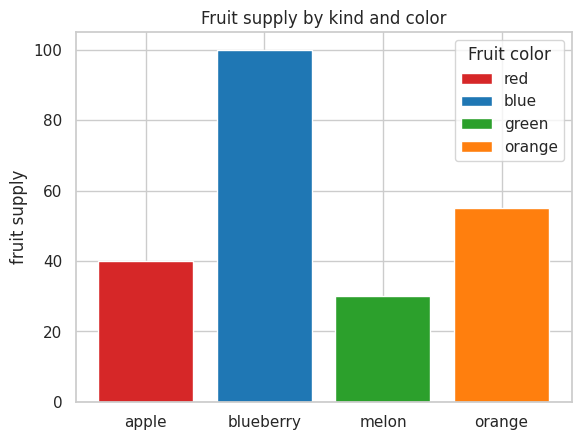

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fruits = ['apple', 'blueberry', 'melon', 'orange']
counts = [40, 100, 30, 55]
bar_labels = ['red', 'blue', 'green', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']

ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

ax.set_ylabel('fruit supply')
ax.set_title('Fruit supply by kind and color')
ax.legend(title='Fruit color')

plt.show()

## Seaborn

<Axes: xlabel='carat', ylabel='price'>

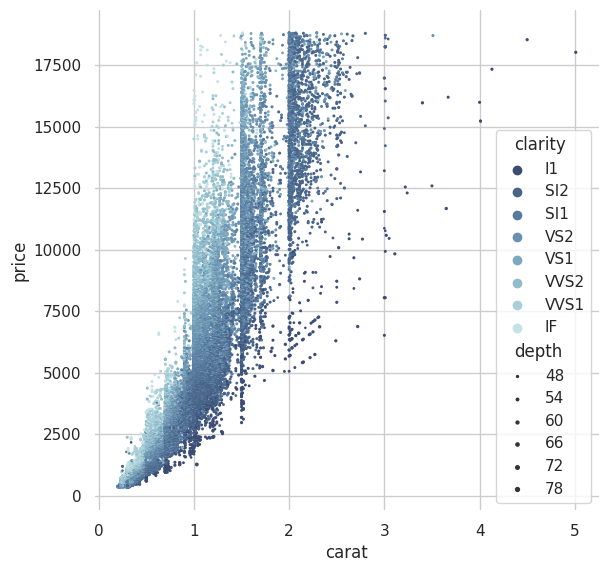

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Load the example diamonds dataset
diamonds = sns.load_dataset("diamonds")

# Draw a scatter plot while assigning point colors and sizes to different
# variables in the dataset
f, ax = plt.subplots(figsize=(6.5, 6.5))
sns.despine(f, left=True, bottom=True)
clarity_ranking = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
sns.scatterplot(x="carat", y="price",
                hue="clarity", size="depth",
                palette="ch:r=-.2,d=.3_r",
                hue_order=clarity_ranking,
                sizes=(1, 8), linewidth=0,
                data=diamonds, ax=ax)

# Measuring Central Tendency with numpy
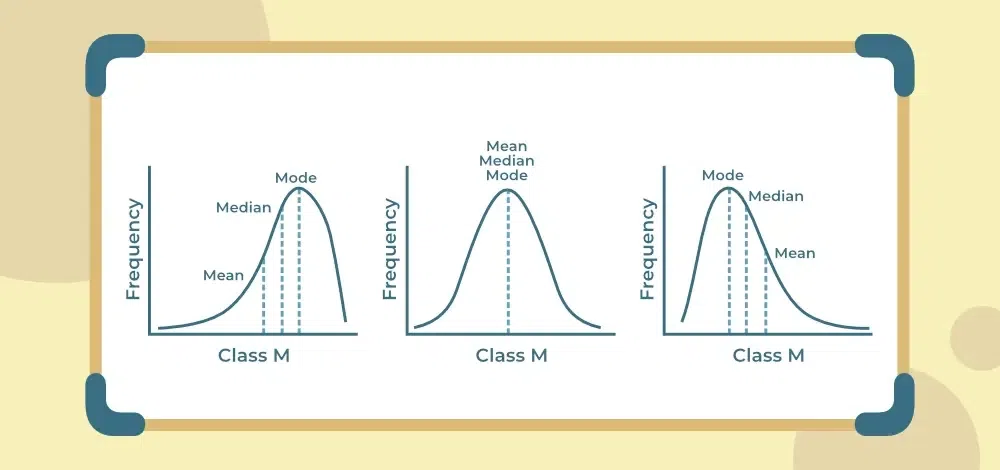

## catatan:
1. Mean dikatkan baik ketika kumpulan data terdistribusi/tersebar secara normal dan tidak ada nilai ekstrem atau outlier yang jauh beda dengan data lain. Selain itu, mean juga dikatakan baik jika keberadaanya paling kecil dari yang lain baik distribusi right maupun left
2. Median dikatakan baik ketika kumpulan data itu miring skew right/skew left atau terdapat outlier(yang membuat dia naik turun seperti halnya miring)
3. Mode dikatakan baik ketika kumpulan data terlihat puncak yang jelas baik. Ini menunjukan bahwa ada beberapa/satu nilai yang muncul sering tapi jumlahnya simetris sehingga mode berada ditengah distribusi antara mean dan median.

In [ ]:
jumlah_kucing = np.array([3, 2, 1, 1, 2, 3, 2, 1, 0, 2])

## Mean

In [ ]:
jumlah_kucing.mean()

1.7

## Median

In [ ]:
np.median(jumlah_kucing)

2.0

## Mode dua versi

In [ ]:
# with scipy library
from scipy import stats as st
mode_jumlah_kucing = st.mode(jumlah_kucing)[0]
mode_jumlah_kucing

2

# Measuring Dispersion

In [ ]:
# kumpulan data
import numpy as np
jumlah_kucing = np.array([3, 2, 1, 1, 2, 3, 2, 1, 0, 2])

## Range

In [ ]:
range = jumlah_kucing.max() - jumlah_kucing.min()
print(jumlah_kucing.max())
print(jumlah_kucing.min())
range

3
0


3

## Interquartile Range

In [ ]:
iqr = np.percentile(jumlah_kucing, 75) - np.percentile(jumlah_kucing, 25)
iqr

1.0

### karena bisa digunakan untuk mengatasi outliers yang rumusnya Q1-1.5 * IQR dan Q3+1.5 * IQR. 1.5 adalah konstanta.

In [ ]:
# contoh code perhitungan iqr for detect outlier
import numpy as np

# Dataset
data = np.array([6, 7, 15, 36, 39, 40, 41, 42, 43, 47, 49])

# Menghitung Q1 dan Q3
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

# Menghitung IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 25.5
Q3: 42.5
IQR: 17.0


## catatan
* 1.5 itu batas yang aman dari pengaruh outliers dan data ekstrem yang telah diaplikasikan di statistik. Intinya dengan konstanta itu, hasil data yang diambil untuk menghidari outlier sekitar 99.3% dan itu sudah paling banyak dan aman sejauh ini.

## Variance

Parameter variance menjadi penting karena:

* Overfitting: Model dengan variance tinggi cenderung overfitting, yaitu terlalu mendekati atau bahkan mencocokkan noise dalam data pelatihan, yang dapat mengurangi kinerja pada data baru.

* Generalisasi: Model yang memiliki variance yang rendah lebih cenderung menghasilkan prediksi yang konsisten pada data yang belum pernah dilihat sebelumnya (data uji atau data di luar sampel pelatihan).

* Stabilitas: Variance yang rendah menunjukkan bahwa model tidak terlalu bergantung pada perubahan kecil dalam data pelatihan, sehingga lebih stabil dan dapat diandalkan.

* Code variance ada dua versi, tapi bisa beda tujuan atau hasil dan sama tujuan dan habil.
* Numpy menyediakan var() method dan Pandas juga menyediakan var() method.
* Tujuan perhitungan var dibagi menjadi dua, yaitu var untuk data populasi dan data sampel. Data populasi bertujuan jika data sudah terkumpul dan ingin dilakukan analisis ketepatan secara menyeluruh. Data sampel bertujuan untuk keperluan uji/analisis data yang masih belum ditemukan dan diketahui kepastian seluruhnya sehingga diambil sampel sbg perwakilan.
* Pandas sendiri hanya terkhusus untuk data populasi. Sementara, numpy ada keduanya.

In [ ]:
#Numpy populasi
varpop = np.var(jumlah_kucing)
varpop
# nump sample
varsam = np.var(jumlah_kucing, ddof=1)
varsam

0.8100000000000002

In [ ]:
# pandas populasi
import pandas as pd
varpan = pd.Series(jumlah_kucing)
p = varpan.var()
print(p)

0.9000000000000001


## Standard Deviation

In [ ]:
std = np.std(jumlah_kucing)
print(std)#cara pertama
print(var**(1/2)) #cara kedua

0.9000000000000001
0.9000000000000001


# Measuring Asymmetric

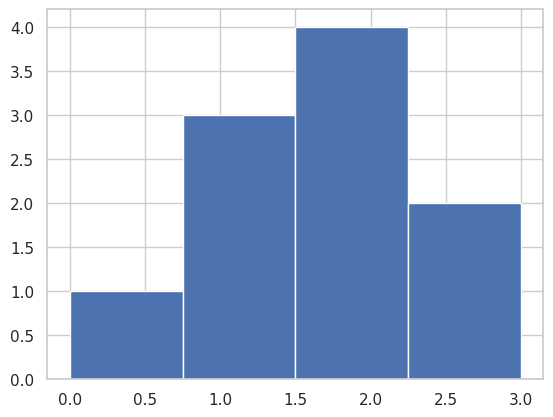

In [ ]:
plt.hist(jumlah_kucing, bins=4)
plt.show()

## Symmetric Distribution

Mean: 4.0
Median: 4.0
Mode: ModeResult(mode=4, count=4)


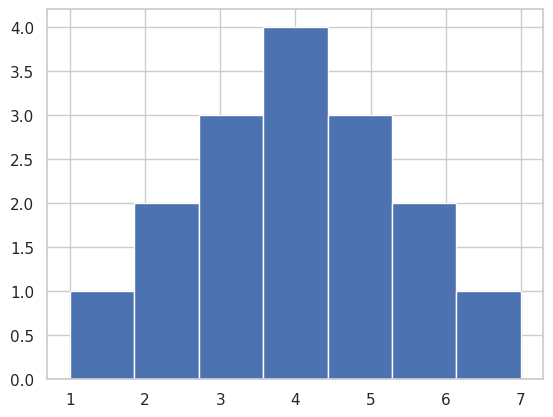

In [ ]:
symmetric = np.array([1,2,2,3,3,3,4,4,4,4,5,5,5,6,6,7])
plt.hist(symmetric, bins=7)
print("Mean:", np.mean(symmetric))
print("Median:", np.median(symmetric))
print("Mode:", st.mode(symmetric))
plt.show()

## Right-Skewed Distribution

Mean: 2.3333333333333335
Median: 2.0
Mode: ModeResult(mode=1, count=5)


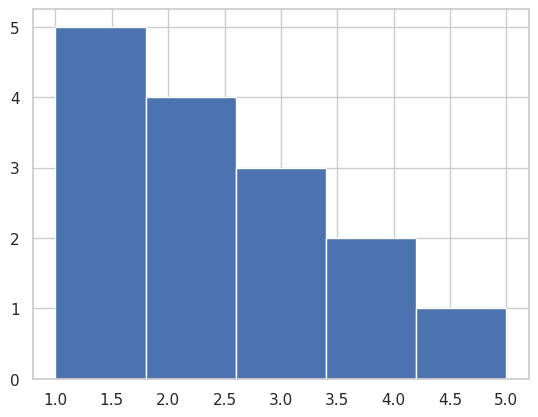

In [ ]:
right_skewed = np.array([1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 5])
plt.hist(right_skewed, bins=5)
print("Mean:", np.mean(right_skewed))
print("Median:", np.median(right_skewed))
print("Mode:", st.mode(right_skewed))
plt.show()

## Left-Skewed Distribution

Mean: 3.6666666666666665
Median: 4.0
Mode: ModeResult(mode=5, count=5)


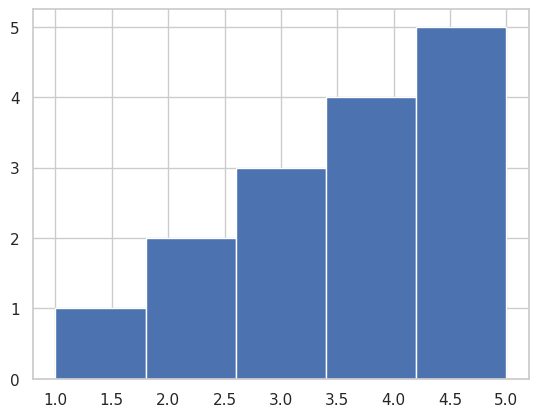

In [ ]:
left_skewed = np.array([5, 5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 3, 2, 2, 1])
plt.hist(left_skewed, bins=5)
print("Mean:", np.mean(left_skewed))
print("Median:", np.median(left_skewed))
print("Mode:", st.mode(left_skewed))
plt.show()

## Skewness

In [ ]:
jumlah_kucing_series = pd.Series(jumlah_kucing)
jumlah_kucing_series.skew()

-0.2342427896421018

## Nol

In [ ]:
Symmetric = np.array([1,2,2,3,3,3,4,4,4,4,5,5,5,6,6,7])
Symmetric = pd.Series(Symmetric)
Symmetric.skew()

0.0

## Positive

In [ ]:
right_skewed = np.array([1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 5])
right_skewed = pd.Series(right_skewed)
right_skewed.skew()

0.6554279508966392

## Negative

In [ ]:
left_skewed = np.array([5, 5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 3, 2, 2, 1])
left_skewed = pd.Series(left_skewed)
left_skewed.skew()

-0.6554279508966392

# Data Relationship

In [ ]:
sample_data = {
    'name': ['Minji', 'Hanni', 'Danniele', 'Haerin', 'Hyein'],
    'age': [24, 22, 23, 25, 28],
    'communication_skill_score': [85, 70, 75, 90, 90],
    'quantitative_skill_score': [80, 90, 80, 75, 70]
}

df = pd.DataFrame(sample_data)

## Correlation

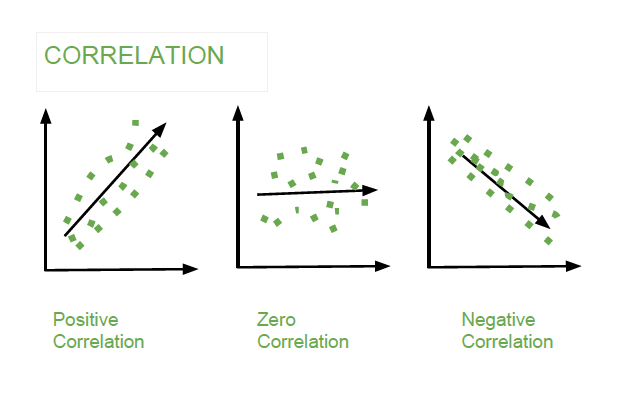

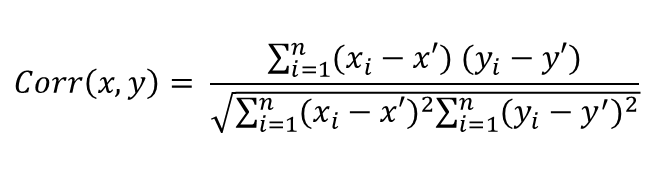

In [ ]:
df.corr(numeric_only=True)

,age,communication_skill_score,quantitative_skill_score
age,1.000000,0.848855,-0.922489
communication_skill_score,0.848855,1.000000,-0.890724
quantitative_skill_score,-0.922489,-0.890724,1.000000


## Covariance

rumus:
* data populasi
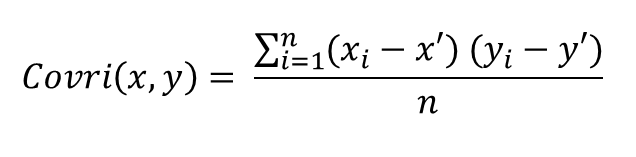

* data sampel
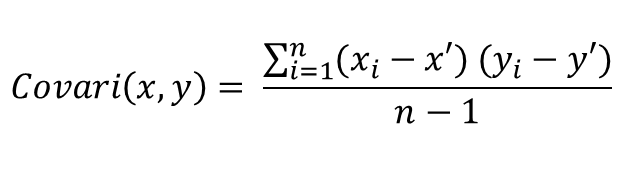

contoh gambar grafik:
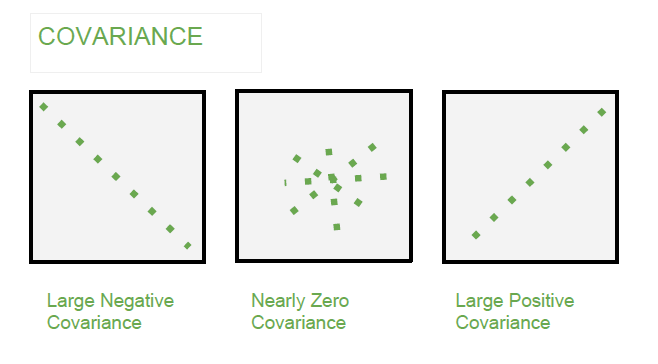

ket:
* Nilainya bisa berapa saja antara -infinity hingga +infinity, dimana nilai negatif mewakili hubungan negatif sedangkan nilai positif mewakili hubungan positif.
* jika + maka hubungan searah, jika - maka berlainan arah.
 Namun sayang dia tidak memiliki informasi yang lebih komperhensif mengenai kuatnya hubungan linear dua variabel. Parameter yang lebih terstandarisasi adalah korelasi.

In [ ]:
df.cov(numeric_only=True)

,age,communication_skill_score,quantitative_skill_score
age,5.30,17.75,-15.75
communication_skill_score,17.75,82.50,-60.00
quantitative_skill_score,-15.75,-60.00,55.00


In [ ]:
import numpy as np

# Dataset
X = np.array([2, 3, 4, 5, 6])
Y = np.array([8, 7, 6, 5, 4])

# Menghitung covariance matrix
cov_matrix = np.cov(X, Y)

print("Covariance Matrix:")
print(cov_matrix)

# Covariance antara X dan Y (off-diagonal element)
cov_XY = cov_matrix[0, 1]

print("Covariance between X and Y:", cov_XY)


Covariance Matrix:
[[ 2.5 -2.5]
 [-2.5  2.5]]
Covariance between X and Y: -2.5


# 1. Data Gathering

## CSV

In [ ]:
df = pd.read_csv("data.csv", delimiter=",", encoding='unicode_escape')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## XLSX atau XLS

In [ ]:
df = pd.read_excel("data.xlsx", sheet_name="Sheet1")

## JSON

In [ ]:
df = pd.read_json("data.json")

## HTML

In [ ]:
url = "https://www.fdic.gov/resources/resolutions/bank-failures/failed-bank-list"
df = pd.read_html(url)[0]
df

,Bank NameBank,CityCity,StateSt,CertCert,Acquiring InstitutionAI,Closing DateClosing,FundFund
0,Citizens Bank,Sac City,IA,8758,Iowa Trust & Savings Bank,"November 3, 2023",10545
1,Heartland Tri-State Bank,Elkhart,KS,25851,"Dream First Bank, N.A.","July 28, 2023",10544
2,First Republic Bank,San Francisco,CA,59017,"JPMorgan Chase Bank, N.A.","May 1, 2023",10543
3,Signature Bank,New York,NY,57053,"Flagstar Bank, N.A.","March 12, 2023",10540
4,Silicon Valley Bank,Santa Clara,CA,24735,First–Citizens Bank & Trust Company,"March 10, 2023",10539
...,...,...,...,...,...,...,...
563,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB","July 27, 2001",6004
564,Malta National Bank,Malta,OH,6629,North Valley Bank,"May 3, 2001",4648
565,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,"February 2, 2001",4647
566,National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,"December 14, 2000",4646


## XML

In [ ]:
df = pd.read_xml("https://www.w3schools.com/xml/books.xml")
df

,category,title,author,year,price,cover
0,cooking,Everyday Italian,Giada De Laurentiis,2005,30.00,None
1,children,Harry Potter,J K. Rowling,2005,29.99,None
2,web,XQuery Kick Start,Vaidyanathan Nagarajan,2003,49.99,None
3,web,Learning XML,Erik T. Ray,2003,39.95,paperback


# 2. Exploratory Data Analysist(EDA)

# Assessing Data

## Simplex
1. isnull(): method untuk mendeteksi missing value sebuah dataset
2. duplicated()

## Check Characteristic Data

In [ ]:
import pandas as pd
df = pd.read_csv("data_car.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,jumlahTempatTIdur,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


## Missing Value

In [ ]:
product_df = pd.read_csv("data.csv", encoding='unicode_escape')
product_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Duplicate Data

In [ ]:
product_df.duplicated().sum()

5268

## check the outlier

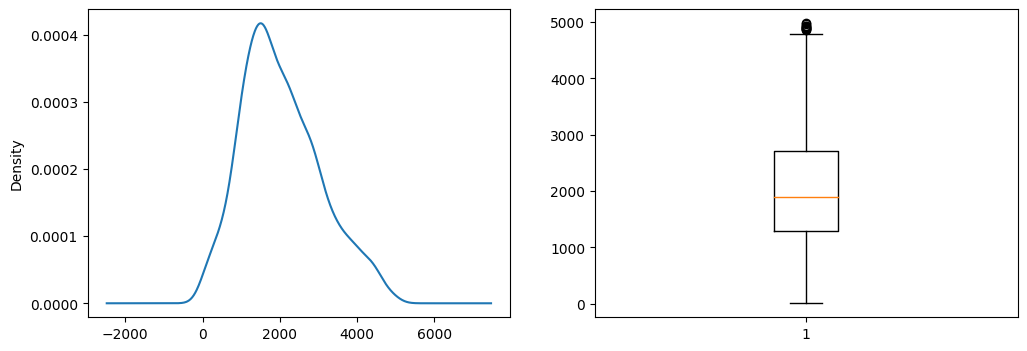

In [ ]:
import matplotlib.pyplot as plt
f = plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['total_rooms'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['total_rooms'])
plt.show()

# Cleaning Data

## Missing Value

### Dropping

In [ ]:
products_df = pd.read_csv("data.csv", encoding='unicode_escape')
products_df.dropna(axis=0, inplace=True)

In [ ]:
products_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## removing data duplicated

In [ ]:
df = df.drop_duplicates(subset='MSRP', keep='first')
df.count()

Make                 6049
Model                6049
Year                 6049
Engine Fuel Type     6048
Engine HP            6014
Engine Cylinders     6034
Transmission Type    6049
Driven_Wheels        6049
Number of Doors      6044
Market Category      4285
Vehicle Size         6049
Vehicle Style        6049
highway MPG          6049
city mpg             6049
Popularity           6049
MSRP                 6049
dtype: int64

## remove format symbol


In [ ]:
df['MSRP'] = [x.replace('$', '') for x in df['MSRP']]
df['MSRP'] = [x.replace(',', '') for x in df['MSRP']]

AttributeError: 'int' object has no attribute 'replace'

### itu adalah contoh saja yang harusnya MSRP adalah string

## Converting datatype column

In [ ]:
# contoh datatype int
df['MSRP']=pd.to_numeric(df['MSRP'],errors='coerce')

In [ ]:
#contoh datatype datetime
df['Tanggal_Penutupan'] = pd.to_datetime(df['Tanggal_Penutupan'], format='%B %d, %Y')
df.head()

## Overcome Outlier with statistic IQR/Inter quartile range

<Axes: xlabel='MSRP'>

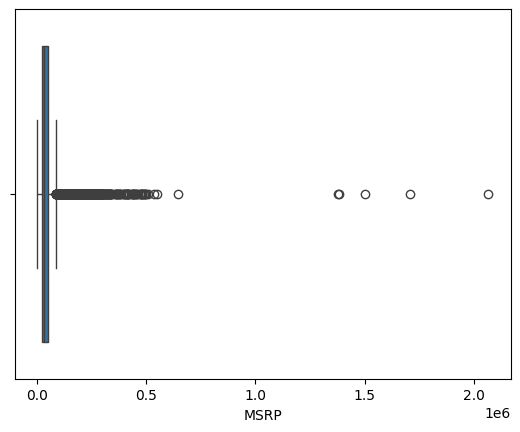

In [ ]:
import seaborn as sns
sns.boxplot(x = df["MSRP"])

In [ ]:
df = df.select_dtypes(include=[float, int])


In [ ]:

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1


In [ ]:
print(IQR)

Year                    8.0
Engine HP             136.0
Engine Cylinders        4.0
Number of Doors         2.0
highway MPG             9.0
city mpg                7.0
Popularity           1482.0
MSRP                26385.0
dtype: float64


In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
p =  df[~((df < (lower_bound)) |(df > (upper_bound))).any(axis=1)]

Outliers:


<Axes: xlabel='MSRP'>

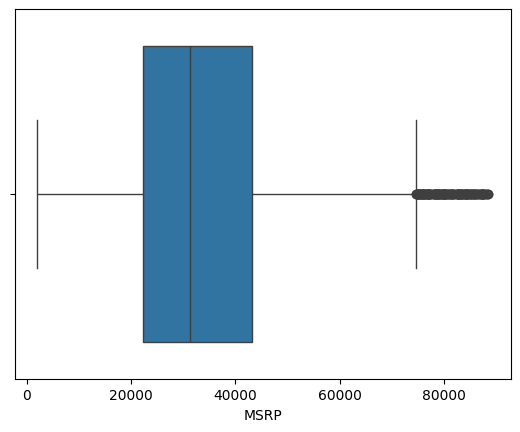

In [ ]:
print('Outliers:')
sns.boxplot(x = p["MSRP"])


In [ ]:
sns.boxplot(x=df['total_rooms'])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Nama_Bank          568 non-null    object
 1   Kota               568 non-null    object
 2   No.Sertifikat      568 non-null    int64 
 3   Lembaga_Akusisi    568 non-null    object
 4   Tanggal_Penutupan  568 non-null    object
 5   Dana               568 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 26.8+ KB


## **Hapus kolom yang tidak relevan**
Tujuanya adalah ketika nanti dataset kita banyak kolom, kita harus menghfilter tuh mana yang kita butuhin aja jadi pakailah cara ini tanpa harus excel atau lain

In [ ]:
df.head()

In [ ]:
df = df.drop(['total_rooms'], axis=1)
df.head(5)

,longitude,latitude,housing_median_age,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,244.0,850.0,237.0,2.9375,81700.0


## Renaming irrelevant column final

In [ ]:
df = df.rename(columns={"total_bedrooms" : "jumlahTempatTIdur"})
df.head(5)

,longitude,latitude,housing_median_age,jumlahTempatTIdur,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,244.0,850.0,237.0,2.9375,81700.0


# Data visualization

## simplex
1. univariate: visualisasi dalam bentuk plot yang menggunakan jenis plot tertentu seperti pie chart, hist, atau lainya yang dimanfaatkan dalam memahami dan menganalisis bagaimana distribusi data variabel secara statistik baik data numerik maupun kategorik.
2. bivariate: visualisasi yang memanfaatkan dua variabel untuk dicari hubungan korelatif keduanya, distribusi data keduanya, trend garis yg dipengaruhi oleh dua variabel, dll. Bisa dalam bentuk scatter, line chart, atau cluster.
3. multivariate: Ini hampir sama dengan bivariate, tapi lebih kompleks dalam visualisasinya karena dia mengkaitkan lebih dari dua variabel. Kadang dan seringnya dalam bentuk cluster dan heatmaps.

## Univariate Analysis

### univariate dari dataframe vs series

In [ ]:
# Dalam bentuk dataframe
import matplotlib.pyplot as plt
import pandas as pd

# Bisa selain struktur data list
# cities = ('Bogor', 'Bandung', 'Jakarta', 'Semarang', 'Yogyakarta',
#           'Surakarta','Surabaya', 'Medan', 'Makassar')

# populations = (45076704, 11626410, 212162757, 19109629, 50819826, 17579085,
#                3481, 287750, 785409)

cities = ['Bogor', 'Bandung', 'Jakarta', 'Semarang', 'Yogyakarta',
          'Surakarta','Surabaya', 'Medan', 'Makassar']

populations = [45076704, 11626410, 212162757, 19109629, 50819826, 17579085,
               3481, 287750, 785409]


# data = {'cities' : ['Bogor', 'Bandung', 'Jakarta', 'Semarang', 'Yogyakarta',
#           'Surakarta','Surabaya', 'Medan', 'Makassar'], 'populations' : [45076704, 11626410, 212162757, 19109629, 50819826, 17579085,
#                3481, 287750, 785409]}
# df = pd.DataFrame(data)
# df

,cities,populations
0,Bogor,45076704
1,Bandung,11626410
2,Jakarta,212162757
3,Semarang,19109629
4,Yogyakarta,50819826
5,Surakarta,17579085
6,Surabaya,3481
7,Medan,287750
8,Makassar,785409


In [ ]:
ss = pd.Series([45076704, 11626410, 212162757, 19109629, 50819826, 17579085,
               3481, 287750, 785409], index=['Bogor', 'Bandung', 'Jakarta', 'Semarang', 'Yogyakarta',
          'Surakarta','Surabaya', 'Medan', 'Makassar'])
print(ss)

Bogor          45076704
Bandung        11626410
Jakarta       212162757
Semarang       19109629
Yogyakarta     50819826
Surakarta      17579085
Surabaya           3481
Medan            287750
Makassar         785409
dtype: int64


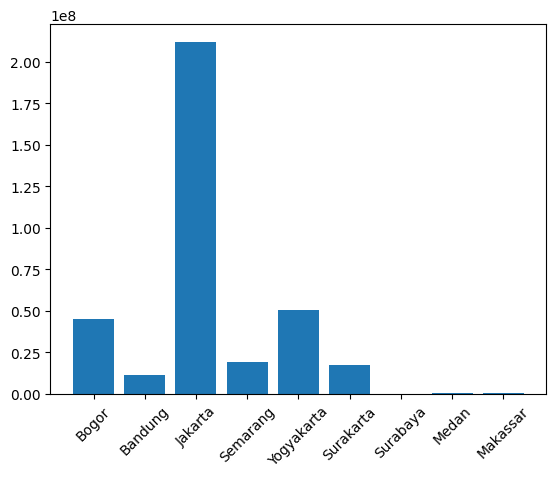

In [ ]:

# univariate versi dataframe
plt.bar(x=df['cities'], height=df['populations'] )
plt.xticks(rotation=45)
plt.show()

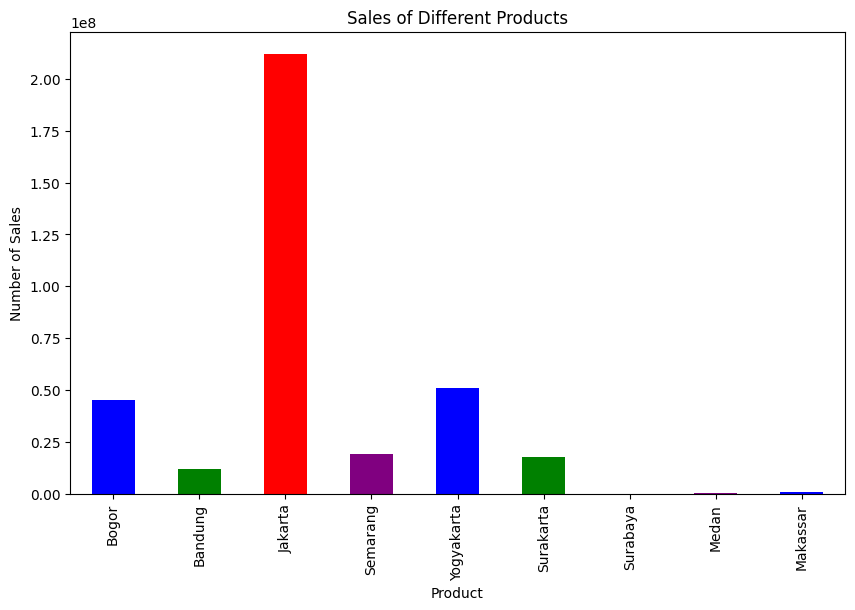

In [ ]:

# univariate versi series
plt.figure(figsize=(10, 6))
ss.plot(kind='bar', color=['blue', 'green', 'red', 'purple'])

# Menambahkan judul dan label
plt.title('Sales of Different Products')
plt.xlabel('Product')
plt.ylabel('Number of Sales')

# Menampilkan plot
plt.show()

* catatan:
1. Jadi kenapa univariate disandingkan pada perbedaan versi dataframe dan series? karena keduanya valid dalam menampilkan univariate analisis. jadi, jangan bingung kalau univariate ini bisa diseries juga.
2. karena series terdiri dari 1 kolom dan 1 index, label adalah index yang biasanya menjadi sumbu x.

### Univariate tidak terbatas dan wajib ada label dan satu kolom. Bahkan tidak hanya terkhusus untuk numerik atau kategorik. semua bisa!

count    9.000000e+00
mean     3.971678e+07
std      6.730608e+07
min      3.481000e+03
25%      7.854090e+05
50%      1.757908e+07
75%      4.507670e+07
max      2.121628e+08
Name: populations, dtype: float64


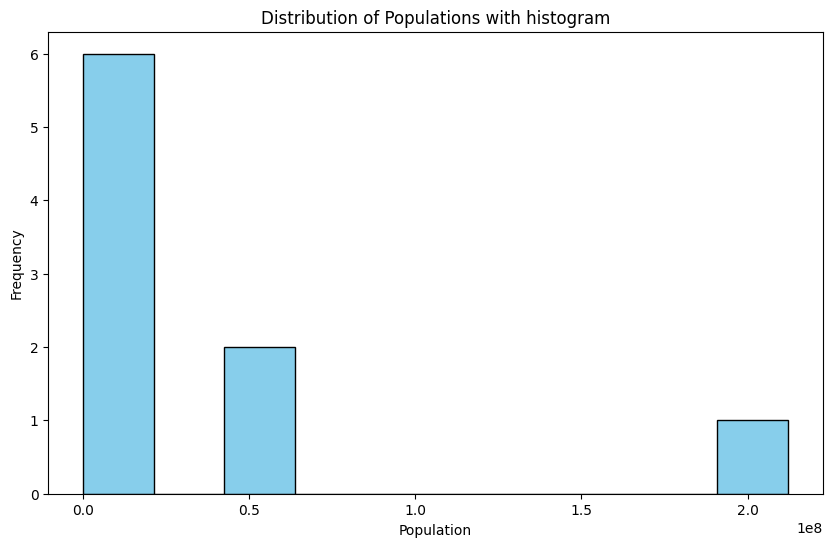

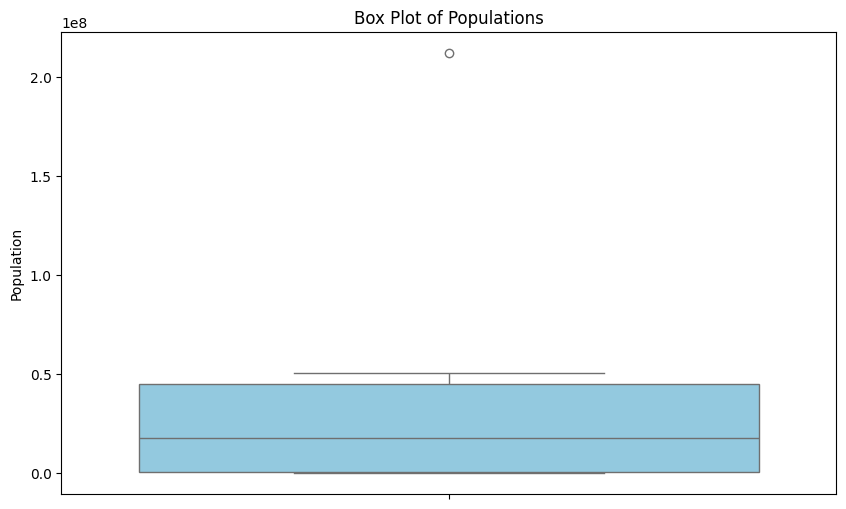

populations_bin
<1M          3
1M-10M       0
10M-50M      4
50M-100M     1
100M-200M    0
>200M        1
Name: count, dtype: int64


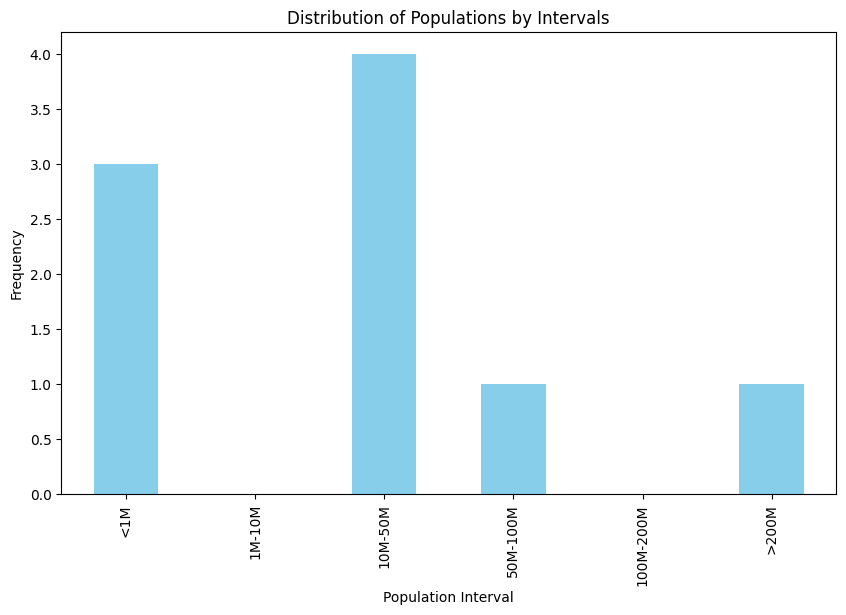

In [ ]:
# versi numerik only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh data numerik
data = {'populations': [45076704, 11626410, 212162757, 19109629, 50819826,
                        17579085, 3481, 287750, 785409]}
df = pd.DataFrame(data)

# Statistik deskriptif
print(df['populations'].describe())

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['populations'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Populations with histogram')
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['populations'], color='skyblue')
plt.title('Box Plot of Populations')
plt.ylabel('Population')
plt.show()


# Mengelompokkan data numerik ke dalam interval (bin)
bin_labels = ['<1M', '1M-10M', '10M-50M', '50M-100M', '100M-200M', '>200M']
df['populations_bin'] = pd.cut(df['populations'],
                               bins=[0, 1e6, 1e7, 5e7, 1e8, 2e8, float('inf')],
                               labels=bin_labels)

# Menghitung frekuensi dari setiap bin
bin_counts = df['populations_bin'].value_counts().sort_index()

# Menampilkan bin counts
print(bin_counts)

# Membuat plot bar
plt.figure(figsize=(10, 6))
bin_counts.plot(kind='bar', color='skyblue')

# Menambahkan judul dan label
plt.title('Distribution of Populations by Intervals')
plt.xlabel('Population Interval')
plt.ylabel('Frequency')

# Menampilkan plot
plt.show()


cities
Bogor         1
Bandung       1
Jakarta       1
Semarang      1
Yogyakarta    1
Surakarta     1
Surabaya      1
Medan         1
Makassar      1
Name: count, dtype: int64


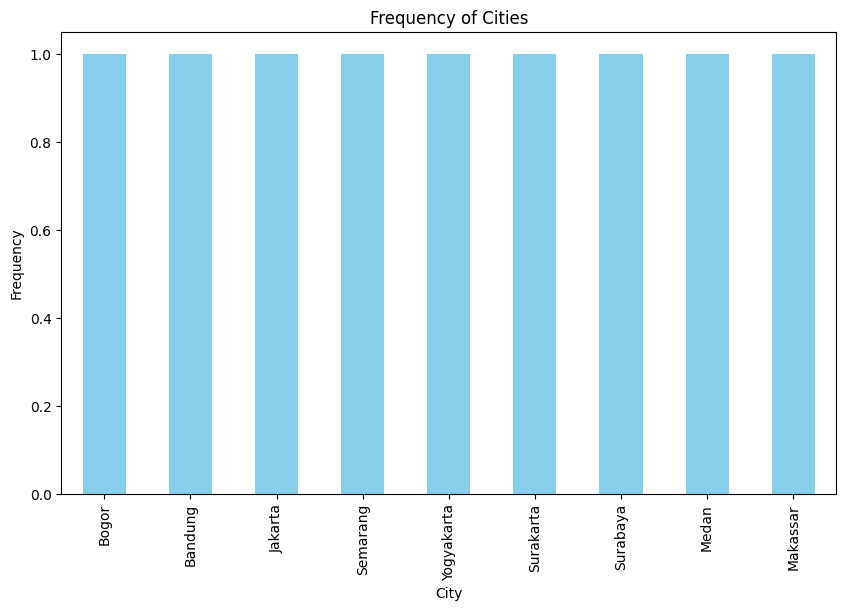

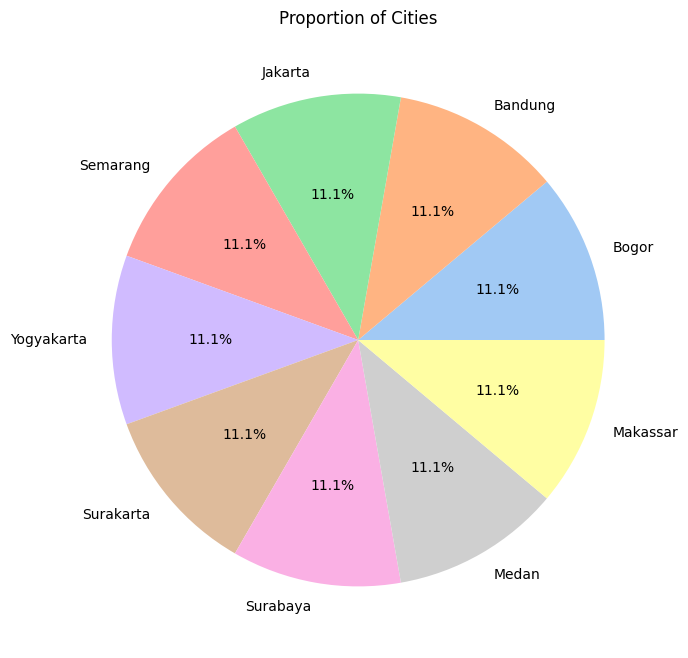

In [ ]:
# versi data kategorik
data = {'cities': ['Bogor', 'Bandung', 'Jakarta', 'Semarang', 'Yogyakarta',
                   'Surakarta', 'Surabaya', 'Medan', 'Makassar']}
df = pd.DataFrame(data)

# Statistik deskriptif
print(df['cities'].value_counts())

# Bar Plot
plt.figure(figsize=(10, 6))
df['cities'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Frequency of Cities')
plt.xlabel('City')
plt.ylabel('Frequency')
plt.show()

# Pie Chart
plt.figure(figsize=(8, 8))
df['cities'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proportion of Cities')
plt.ylabel('')
plt.show()


catatan:
1. untuk kasus linear, pada EDA visualization lebih baik di pisah antara numerical feature dan categorical feature dalam pengemasanya karena itu dapat membantu memudahkan membaca data secara visual.
2. penggunaan bar plot dapat digunakan pada numerical feature dengan bantuan parameter bins


## Bivariate Analysis

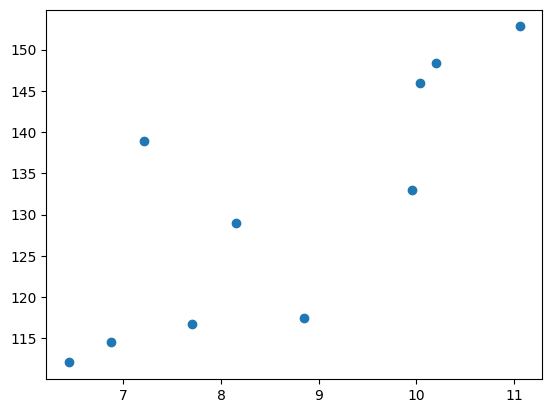

In [ ]:
# versi scater
import matplotlib.pyplot as plt

lemon_diameter = [6.44, 6.87, 7.7, 8.85, 8.15,
                  9.96, 7.21, 10.04, 10.2, 11.06]
lemon_weight = [112.05, 114.58, 116.71, 117.4, 128.93,
                132.93, 138.92, 145.98, 148.44, 152.81]

plt.scatter(x=lemon_diameter, y=lemon_weight)
plt.show()




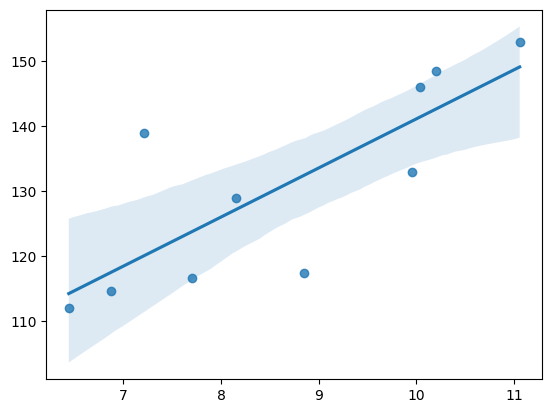

In [ ]:
# versi regplot
sns.regplot(x=lemon_diameter, y=lemon_weight)
plt.show()

### catatan:
1. regplot maksudnya adalah sebuah gradient yang merepresentasikan hubungan korealtif antara dua variabel independent dan dependen dan tren hubungan kedua variabel tersebut.
2. pita disekitar garis itu disebut covidence level atau interval yang mengindikasikan bahwa semakin kecil interval tersebut maka kita dapat lebih yakin bahwa nilai sesungguhnya yang berupa linear ada di dalam pita tersebut

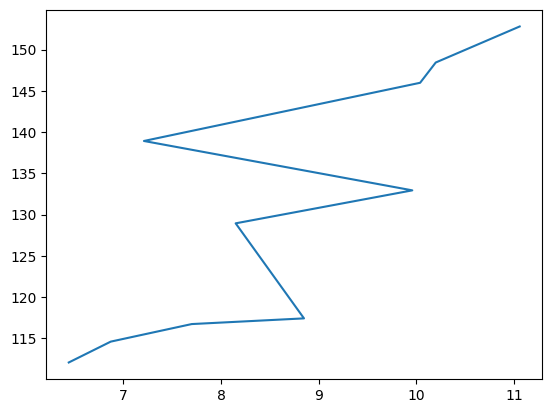

In [ ]:
# versi line chart
import matplotlib.pyplot as plt

lemon_diameter = [6.44, 6.87, 7.7, 8.85, 8.15,
                  9.96, 7.21, 10.04, 10.2, 11.06]
lemon_weight = [112.05, 114.58, 116.71, 117.4, 128.93,
                132.93, 138.92, 145.98, 148.44, 152.81]

plt.plot(lemon_diameter, lemon_weight)
plt.show()

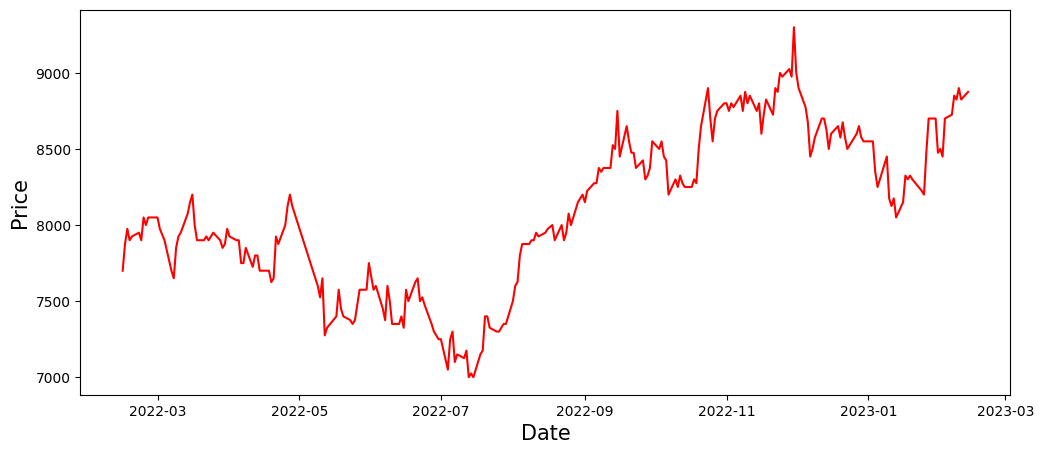

In [ ]:
# line chart untuk kasus time series
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://query1.finance.yahoo.com/v7/finance/download/BBCA.JK?period1=1644796800&period2=1676332800&interval=1d&events=history&includeAdjustedClose=true'
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='red')
plt.xlabel('Date',size=15)
plt.ylabel('Price',size=15)
plt.show()

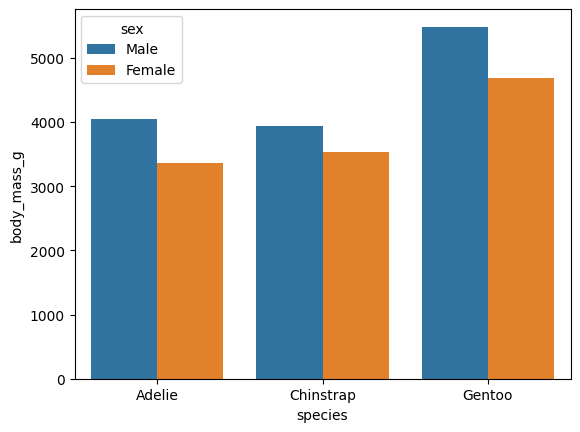

In [ ]:
# versi bar chart
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")

sns.barplot(data=penguins, x="species", y="body_mass_g", hue="sex", errorbar=None)
plt.show()

### catatan:
1. Indikasi yang membedakan antara bivariate dengan multivariate tentunya pada bagian parameter. Jika ada x dan y terdefine maka itu artinya bivariate. selain itu, bisa dianggap multivariate.

In [ ]:
# versi boxplot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://query1.finance.yahoo.com/v7/finance/download/BBCA.JK?period1=1644796800&period2=1676332800&interval=1d&events=history&includeAdjustedClose=true'
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])

df_boxplot = df[["Open"]]


sns.boxplot(data=df_boxplot, palette="rocket")
plt.ylabel('Price',size=15)
plt.show()

## Multivarate Analysis

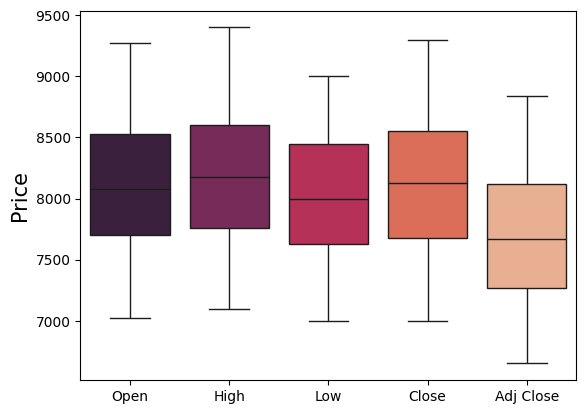

In [ ]:
# versi boxplot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://query1.finance.yahoo.com/v7/finance/download/BBCA.JK?period1=1644796800&period2=1676332800&interval=1d&events=history&includeAdjustedClose=true'
df = pd.read_csv(url)
df['Date'] = pd.to_datetime(df['Date'])

df_boxplot = df[["Open", "High", "Low", "Close", "Adj Close"]]


sns.boxplot(data=df_boxplot, palette="rocket")
plt.ylabel('Price',size=15)
plt.show()

### catatan:
1. Median (Garis Tengah di Kotak): Garis horizontal yang terdapat di dalam kotak menunjukkan median atau nilai tengah data.
2. Garis Antena (Whiskers): adalah garis yang mengiindikasikan rentang mininum dan maksimum nilai price dari masing-masing variabel.
3. IQR adalah retang kotak dari atas - bawah.
4. variabilitas adalah indikasi panjang sebuah kotak. Apabila variabilitas lebih besar maka kotak lebih panjang dan garis antena yang lebih panjang. Intinya panjang box dan antena berbanding lurus dengan besarnya variabilitas suatu data dalam variabel. variabilitas = seberapa tersebar atau variasi data dalam distribusi tsb.

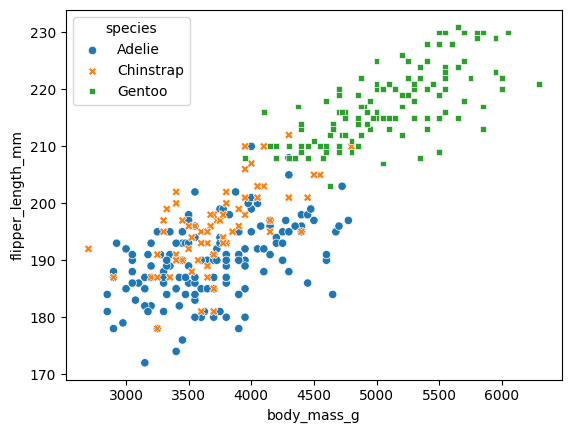

In [ ]:
# versi scatter plot
import seaborn as sns

penguins = sns.load_dataset("penguins")

sns.scatterplot(data=penguins, x="body_mass_g", y="flipper_length_mm", hue="species", style="species")
plt.show()

### catatan:
1. ada dua indikasi visual yang dapat dipahami. Warna titik dan bentuk titik, dan distribusinya.
2. hubungan antar variabel x dengan y. Indikasi positif yang dapat terlihat dari tren distribusi dan peningkatan nilai pada sumbu x terhadap sumbu y di ketiga variabel (di sumbu x).
3. variabilitas dalam spesies:
* Adelie: Memiliki variabilitas yang lebih rendah dibandingkan dengan Chinstrap.Variabilitas yang lebih rendah berarti data lebih terkonsentrasi di sekitar nilai tengahnya, sementara variabilitas yang lebih tinggi berarti data lebih tersebar. jika variabilitas lebih rendah maka kepadatan titik akan berkelompok lebih rapat di sekitar garis tren/pusat data.jarak antar titik pun relatif kecil dan rentangnya pun sempit.jika variabilitas tinggi maka titik akan lebih tersebar dan tidak mengelompok secara padat. jarak antar titik relatif besar dan retangnya pun lebar.
* Chinstrap: Menunjukkan lebih banyak penyebaran data dibandingkan Adelie. Artinya variabilitas tinggi.
* Gentoo: Menunjukkan variabilitas yang signifikan, tetapi umumnya pada rentang nilai yang lebih tinggi dari dua spesies lainnya. Rentang nilai yang lebih tinggi menunjukkan bahwa ada nilai-nilai yang jauh dari median atau nilai tengah, mencakup nilai ekstrem atau outlier.
4. kekuatan hubungan antar variabel:
* Kepadatan Titik: Hubungan yang kuat biasanya ditunjukkan oleh titik-titik yang tersebar secara rapat di sekitar garis tren.
* Kecenderungan Arah: Jika titik-titik menunjukkan pola yang jelas ke arah positif atau negatif, itu menunjukkan hubungan yang kuat. Namun yang jelas, semakin curam tren semakin kuat pula korelasi antar variabelnya.
* Penyebaran Titik: Hubungan yang lemah biasanya ditunjukkan oleh titik-titik yang tersebar secara luas dan tidak mengikuti pola yang jelas.


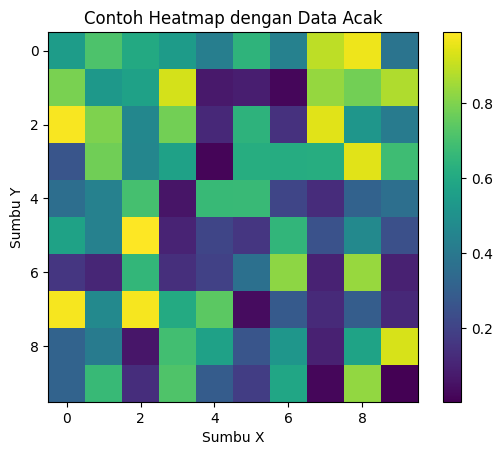

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Membuat data acak untuk heatmap
np.random.seed(0)  # Untuk memastikan hasil yang sama setiap kali dijalankan
data = np.random.rand(10, 10)  # Membuat array 10x10 dengan angka acak antara 0 dan 1

# Membuat heatmap
plt.imshow(data, cmap='viridis', interpolation='nearest')
plt.colorbar()  # Menampilkan bar warna di samping heatmap

# Menambahkan judul dan label
plt.title('Contoh Heatmap dengan Data Acak')
plt.xlabel('Sumbu X')
plt.ylabel('Sumbu Y')

# Menampilkan heatmap
plt.show()


## Beberapa hal penting dalam visualisasi


# 3. Data Preparation